In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
from pathlib import Path

from experiments.mech_interp.block2_stress import load_stress_dataset

DATA_DIR = str(Path('../data').resolve())
N_SAMPLES = 4      # series to plot per panel
SEED = 0

rng = np.random.default_rng(SEED)

# Load index for convenience
idx = np.load(os.path.join(DATA_DIR, 'index.npz'), allow_pickle=True)
cfg = json.loads(str(idx['config_json'][0]))
CTX = cfg['context_patches'] * cfg['patch_len']   # 256
HOR = cfg['horizon_patches'] * cfg['patch_len']   # 64
T   = CTX + HOR                                   # 320

print(f"config: patch_len={cfg['patch_len']}, context={CTX}, horizon={HOR}, n_per_level={cfg['n_per_level']}")
print(f"families:", sorted(set(idx['families'])))

config: patch_len=16, context=256, horizon=64, n_per_level=256
families: ['family_a_periodic', 'family_a_trend', 'family_a_white_noise', 'family_b_outlier', 'family_b_phi', 'family_b_triangle', 'family_c_intermittent', 'family_c_rand_amp']


## Helper

In [3]:
def plot_series(ax, series, ctx, title='', color='steelblue', alpha=0.85):
    """Plot a single series with context/horizon split."""
    ax.axvspan(ctx, len(series), alpha=0.08, color='orange', label='horizon')
    ax.axvline(ctx, color='gray', lw=0.8, ls='--')
    ax.plot(series, color=color, lw=0.9, alpha=alpha)
    ax.set_title(title, fontsize=8)
    ax.tick_params(labelsize=7)

def sample_idxs(n_total, n=N_SAMPLES):
    return rng.choice(n_total, size=min(n, n_total), replace=False)

def load(family, level_key):
    return load_stress_dataset(DATA_DIR, family, level_key)

---
## Family A — Periodic carrier: SNR sweep
Rows = SNR levels (high → low). Each column is a different sample series.

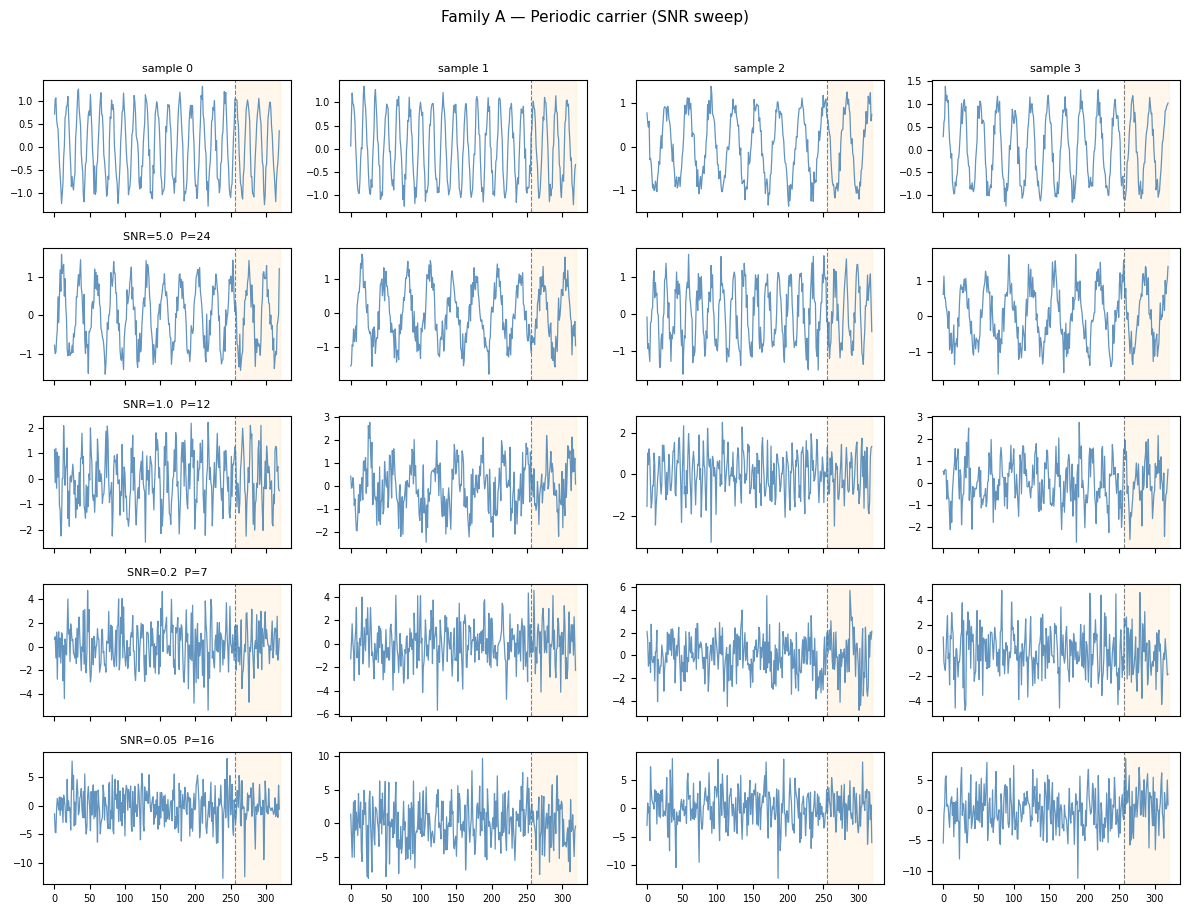

In [7]:
snr_levels = cfg['family_a']['snr_levels']
# Show every other level to keep the plot compact
show_levels = list(range(0, len(snr_levels), 2))

fig, axes = plt.subplots(len(show_levels), N_SAMPLES, figsize=(N_SAMPLES * 3, len(show_levels) * 1.8),
                         sharex=True)
fig.suptitle('Family A — Periodic carrier (SNR sweep)', fontsize=11, y=1.01)

for row, li in enumerate(show_levels):
    snr = snr_levels[li]
    series, meta, _ = load('family_a_periodic', f'snr_{li:02d}')
    idxs = sample_idxs(len(series))
    for col, si in enumerate(idxs):
        ax = axes[row, col]
        title = f'SNR={snr}  P={meta["period_ts"][si]:.0f}' if col == 0 else ''
        plot_series(ax, series[si], CTX, title=title)
        if row == 0:
            ax.set_title(f'sample {col}', fontsize=8)

plt.tight_layout()
plt.show()

## Family A — Trend carrier: SNR sweep

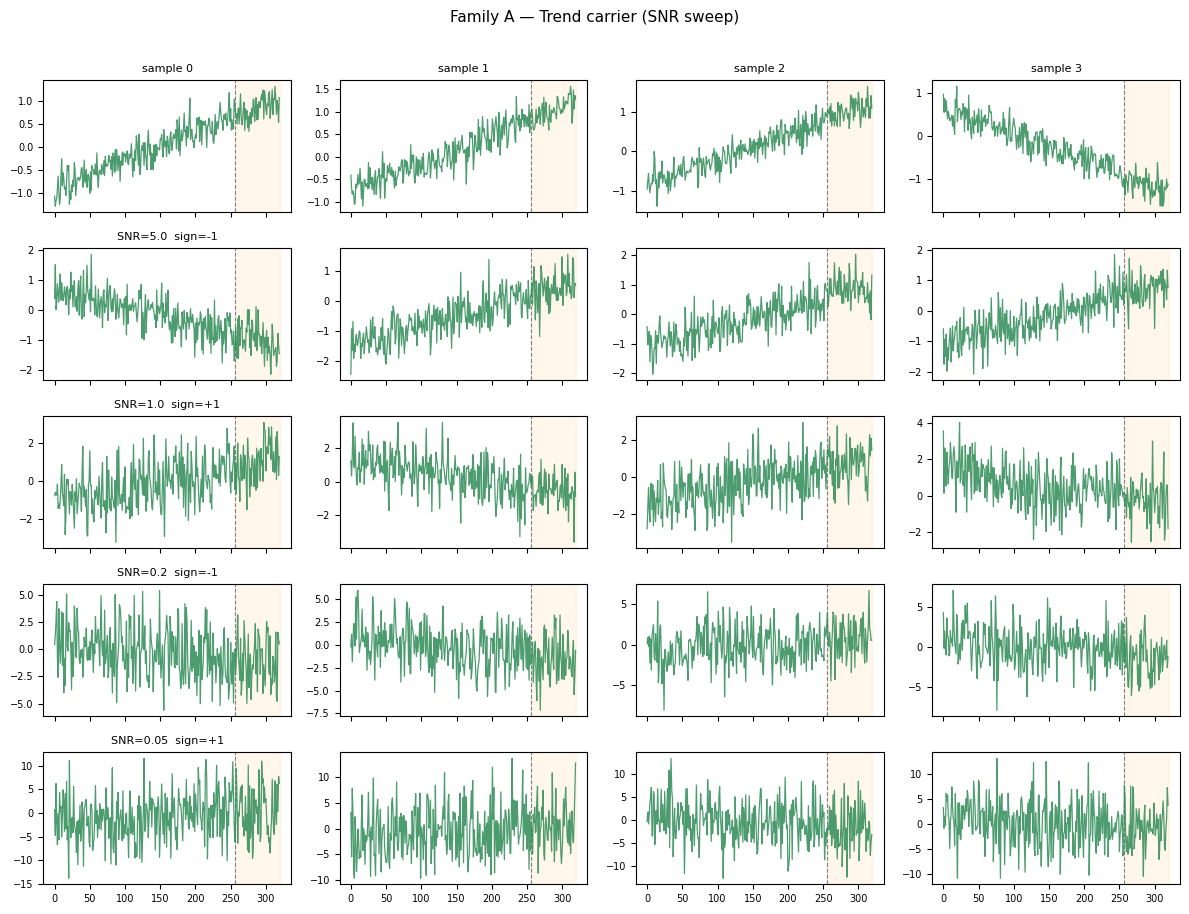

In [8]:
fig, axes = plt.subplots(len(show_levels), N_SAMPLES, figsize=(N_SAMPLES * 3, len(show_levels) * 1.8),
                         sharex=True)
fig.suptitle('Family A — Trend carrier (SNR sweep)', fontsize=11, y=1.01)

for row, li in enumerate(show_levels):
    snr = snr_levels[li]
    series, meta, _ = load('family_a_trend', f'snr_{li:02d}')
    idxs = sample_idxs(len(series))
    for col, si in enumerate(idxs):
        ax = axes[row, col]
        title = f'SNR={snr}  sign={meta["slope_sign"][si]:+.0f}' if col == 0 else ''
        plot_series(ax, series[si], CTX, title=title, color='seagreen')
        if row == 0:
            ax.set_title(f'sample {col}', fontsize=8)

plt.tight_layout()
plt.show()

## Family A — White-noise anchor

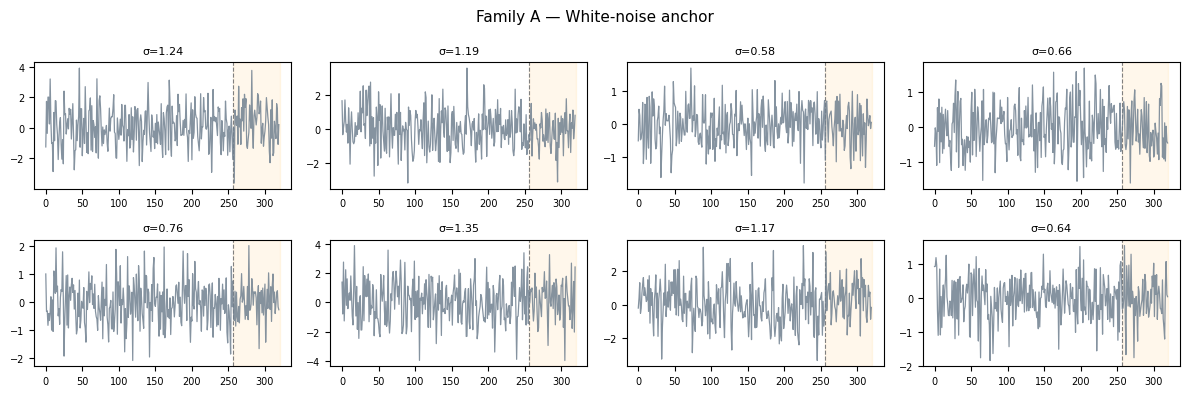

In [9]:
series, meta, _ = load('family_a_white_noise', 'anchor')
idxs = sample_idxs(len(series), n=8)

fig, axes = plt.subplots(2, 4, figsize=(12, 4))
fig.suptitle('Family A — White-noise anchor', fontsize=11)
for ax, si in zip(axes.flat, idxs):
    plot_series(ax, series[si], CTX, title=f'σ={meta["sigma"][si]:.2f}', color='slategray')
plt.tight_layout()
plt.show()

---
## Family B — AR(1) φ-sweep
Each row = one φ value. Watch how the series changes character from anti-persistent (φ<0) to persistent (φ→1).

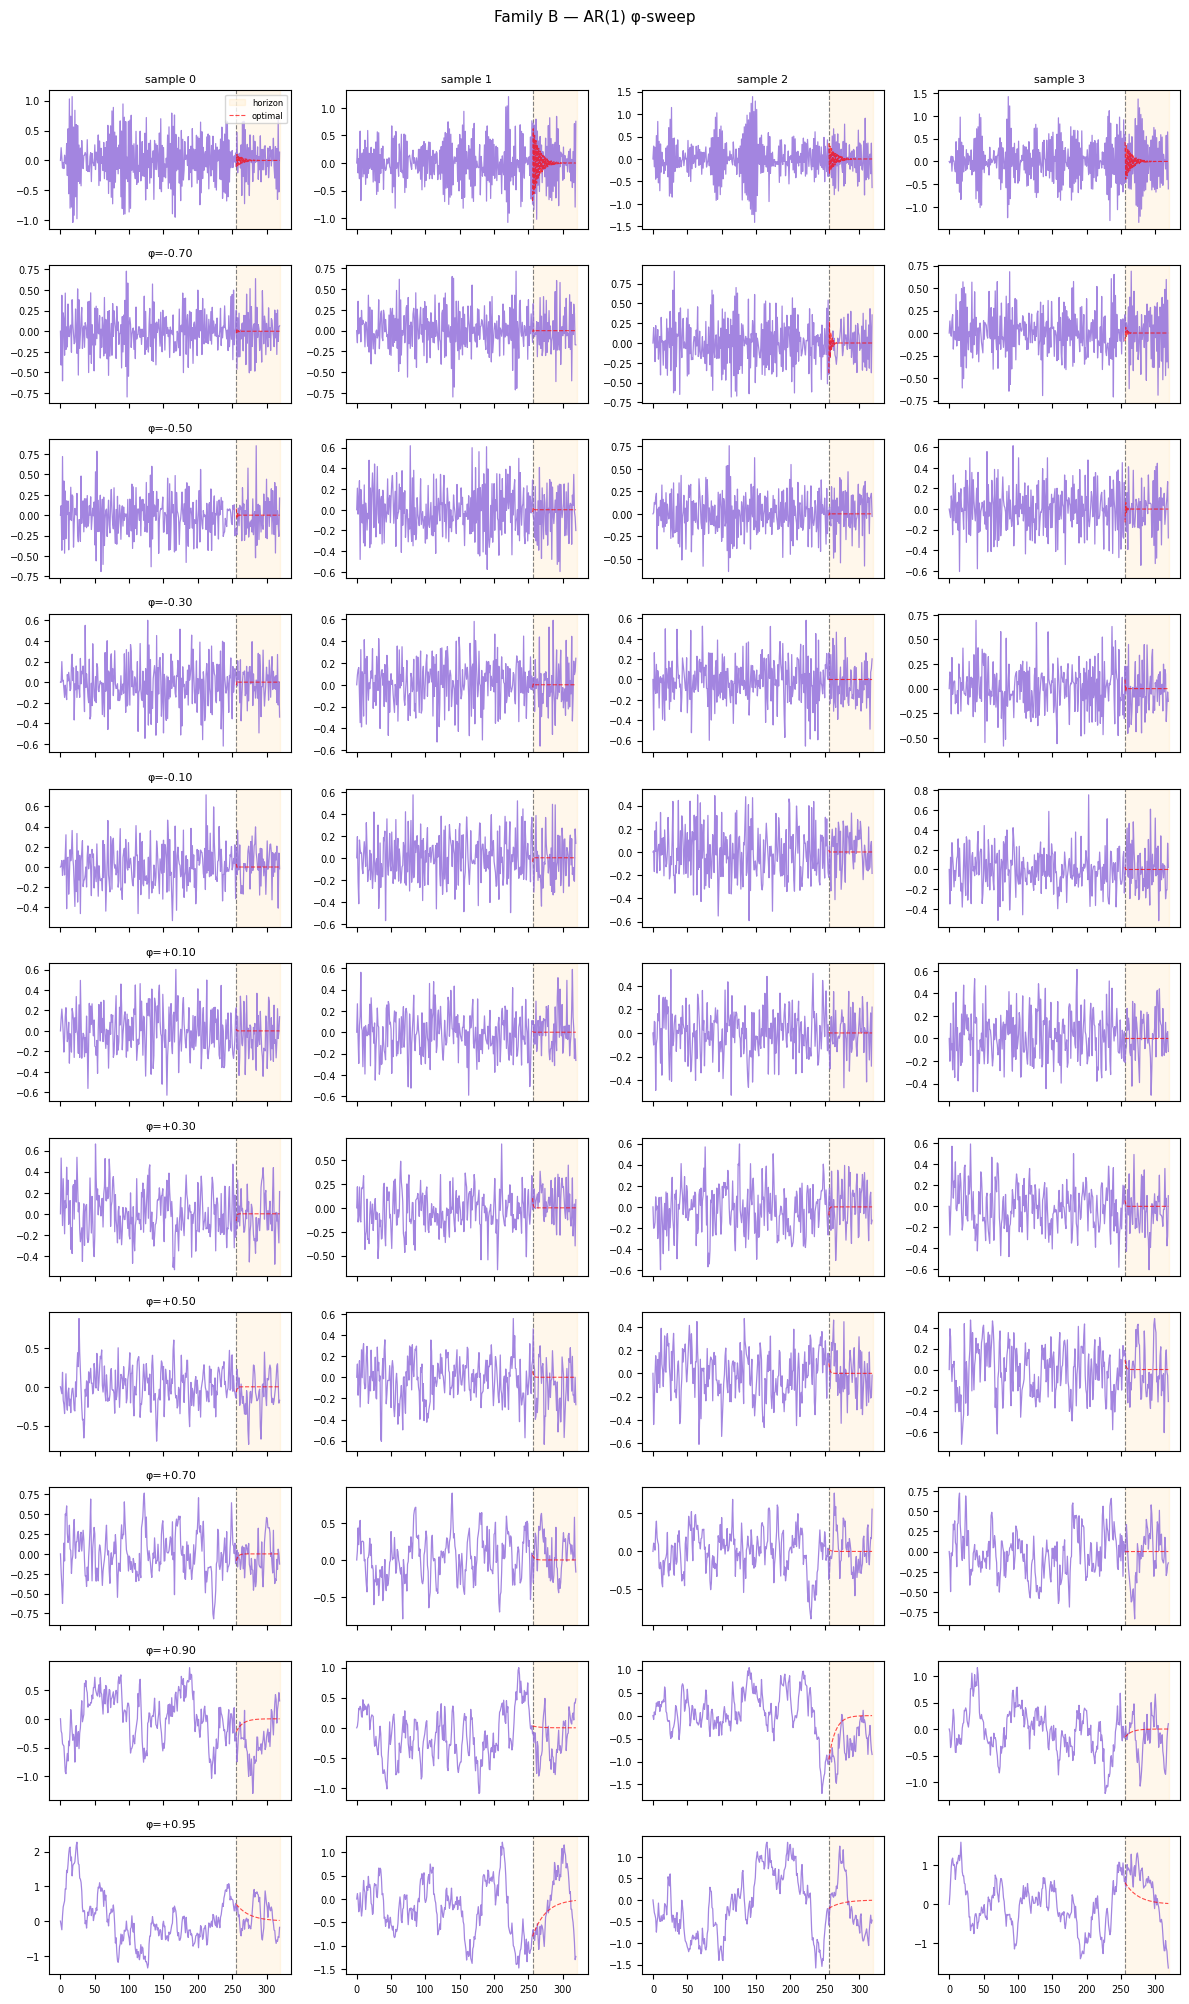

In [11]:
phi_levels = cfg['family_b']['phi_levels']
# Show every other level
show_phi = list(range(0, len(phi_levels), 2))

fig, axes = plt.subplots(len(show_phi), N_SAMPLES, figsize=(N_SAMPLES * 3, len(show_phi) * 1.8),
                         sharex=True)
fig.suptitle('Family B — AR(1) φ-sweep', fontsize=11, y=1.01)

for row, li in enumerate(show_phi):
    phi = phi_levels[li]
    series, meta, _ = load('family_b_phi', f'phi_{li:02d}')
    idxs = sample_idxs(len(series))
    for col, si in enumerate(idxs):
        ax = axes[row, col]
        title = f'φ={phi:+.2f}' if col == 0 else ''
        plot_series(ax, series[si], CTX, title=title, color='mediumpurple')
        # Overlay analytic optimal continuation in horizon
        opt = meta['optimal_continuation'][si]
        ax.plot(np.arange(CTX, CTX + HOR), opt, color='red', lw=0.8, ls='--', alpha=0.7,
                label='optimal' if col == 0 and row == 0 else '')
        if row == 0:
            ax.set_title(f'sample {col}', fontsize=8)

axes[0, 0].legend(fontsize=6, loc='upper right')
plt.tight_layout()
plt.show()

## Family B — Outlier δ-sweep
Spike injected at the last context timestep. Rows = δ (in units of context std).

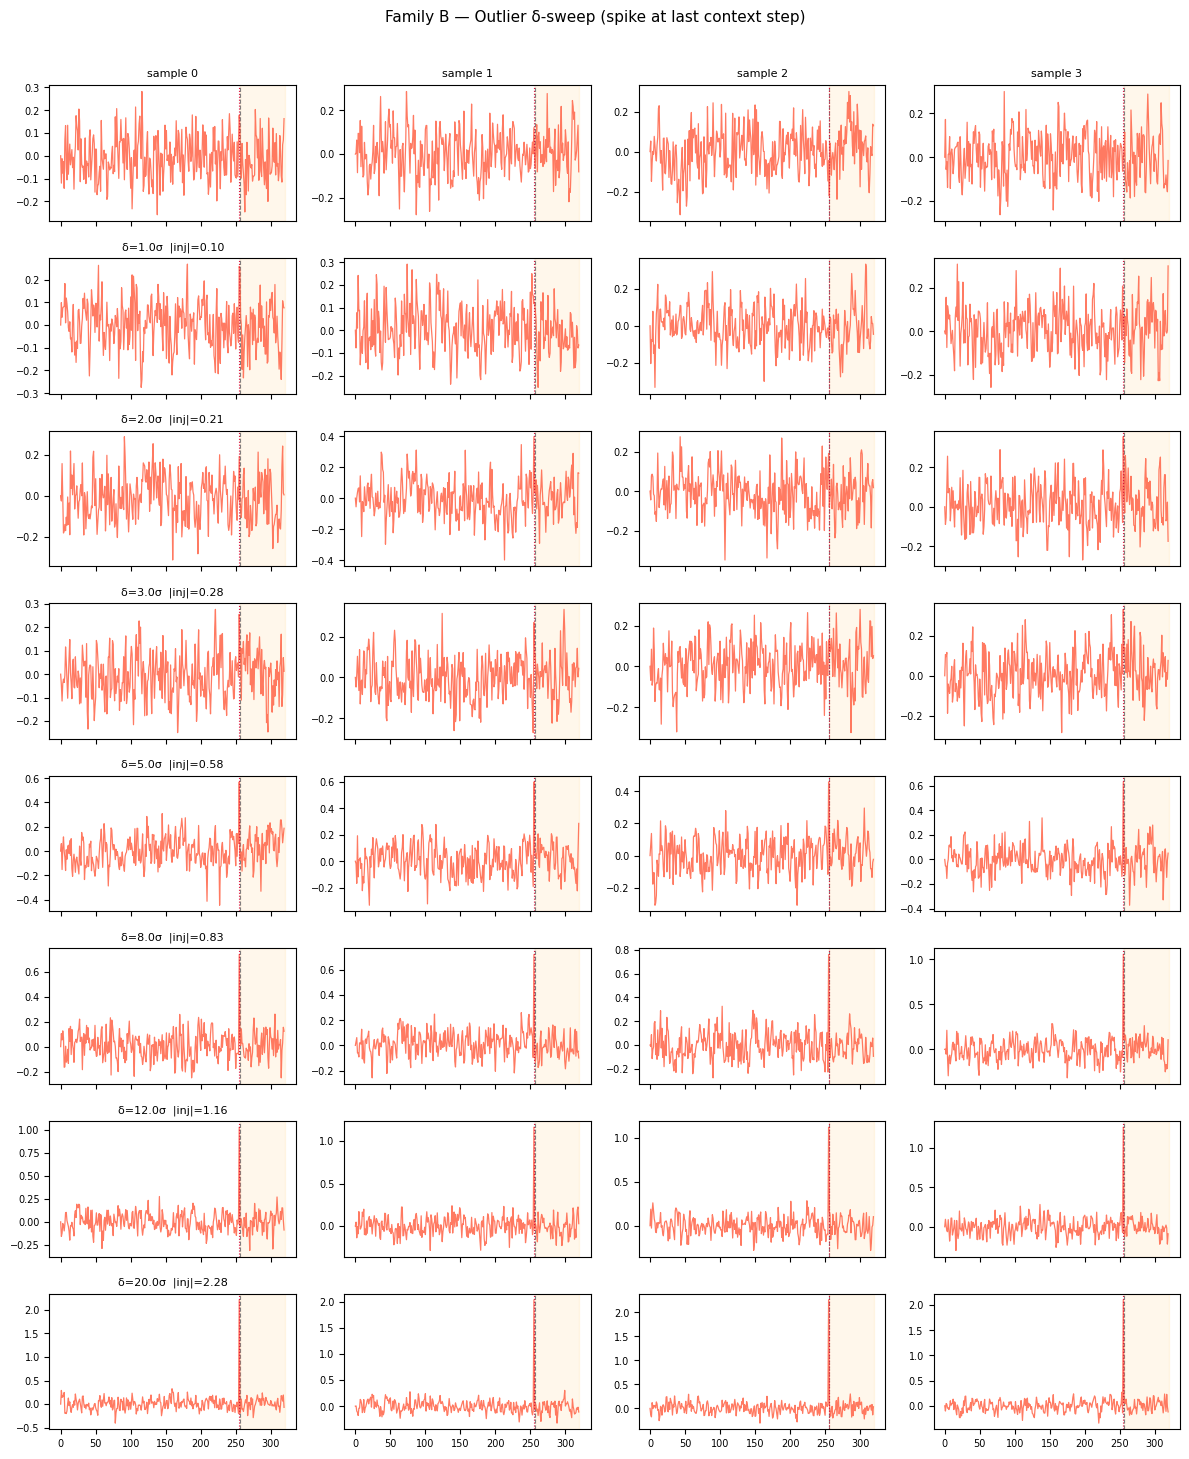

In [12]:
outlier_deltas = cfg['family_b']['outlier_deltas']

fig, axes = plt.subplots(len(outlier_deltas), N_SAMPLES, figsize=(N_SAMPLES * 3, len(outlier_deltas) * 1.8),
                         sharex=True)
fig.suptitle('Family B — Outlier δ-sweep (spike at last context step)', fontsize=11, y=1.01)

for row, (li, delta) in enumerate(zip(range(len(outlier_deltas)), outlier_deltas)):
    series, meta, _ = load('family_b_outlier', f'delta_{li:02d}')
    idxs = sample_idxs(len(series))
    for col, si in enumerate(idxs):
        ax = axes[row, col]
        title = f'δ={delta}σ  |inj|={meta["injected_delta"][si]:.2f}' if col == 0 else ''
        plot_series(ax, series[si], CTX, title=title, color='tomato')
        # Mark the spike location
        ax.axvline(CTX - 1, color='crimson', lw=0.8, ls=':')
        if row == 0:
            ax.set_title(f'sample {col}', fontsize=8)

plt.tight_layout()
plt.show()

## Family B — Triangle diagnostic
Piecewise-linear triangle wave; apex (marked with ▽) is placed inside the horizon.

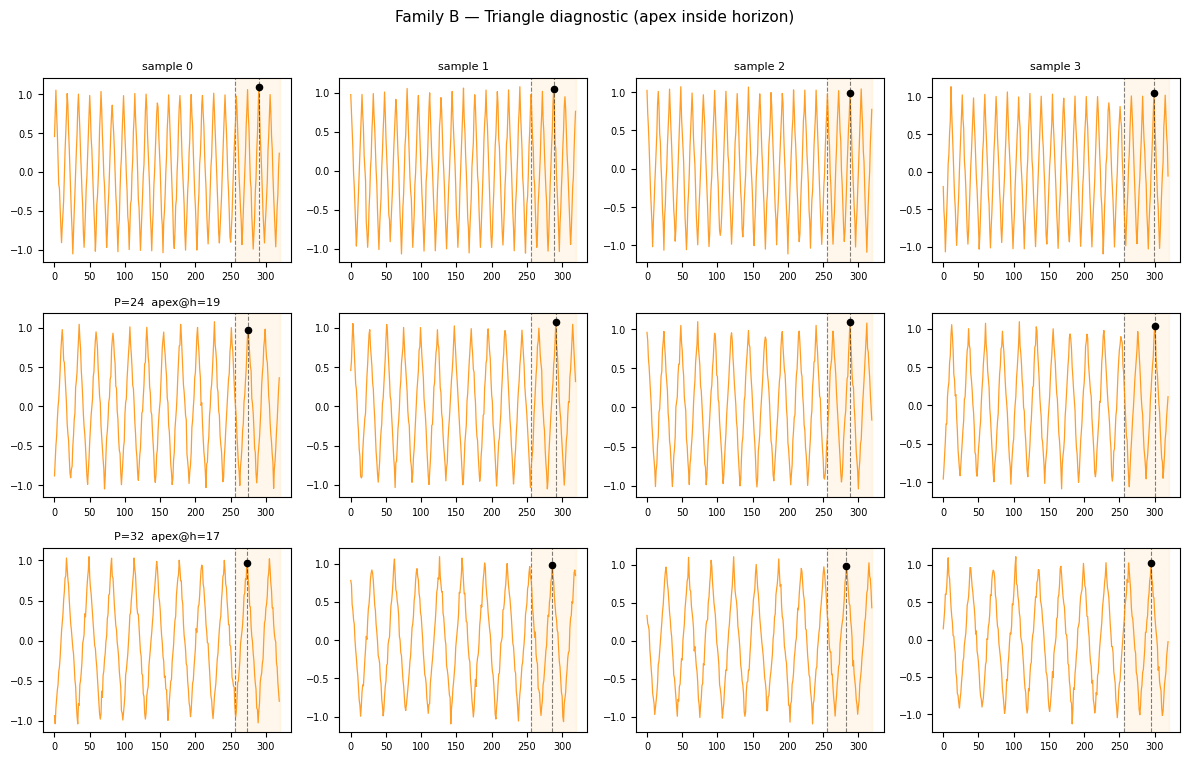

In [13]:
period_bins = cfg['family_b']['triangle_period_bins']

fig, axes = plt.subplots(len(period_bins), N_SAMPLES, figsize=(N_SAMPLES * 3, len(period_bins) * 2.5))
fig.suptitle('Family B — Triangle diagnostic (apex inside horizon)', fontsize=11, y=1.01)

for row, pi in enumerate(range(len(period_bins))):
    series, meta, _ = load('family_b_triangle', f'period_{pi:02d}')
    idxs = sample_idxs(len(series))
    for col, si in enumerate(idxs):
        ax = axes[row, col]
        apex_h = int(meta['apex_h'][si])
        P = int(meta['period_ts'][si])
        title = f'P={P}  apex@h={apex_h}' if col == 0 else ''
        plot_series(ax, series[si], CTX, title=title, color='darkorange')
        # Mark apex
        apex_t = CTX + apex_h
        ax.axvline(apex_t, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.scatter([apex_t], [series[si, apex_t]], color='black', s=20, zorder=5)
        if row == 0:
            ax.set_title(f'sample {col}', fontsize=8)

plt.tight_layout()
plt.show()

---
## Family C — Intermittent events
Rows = Bernoulli probability p. Higher p → denser bumps.

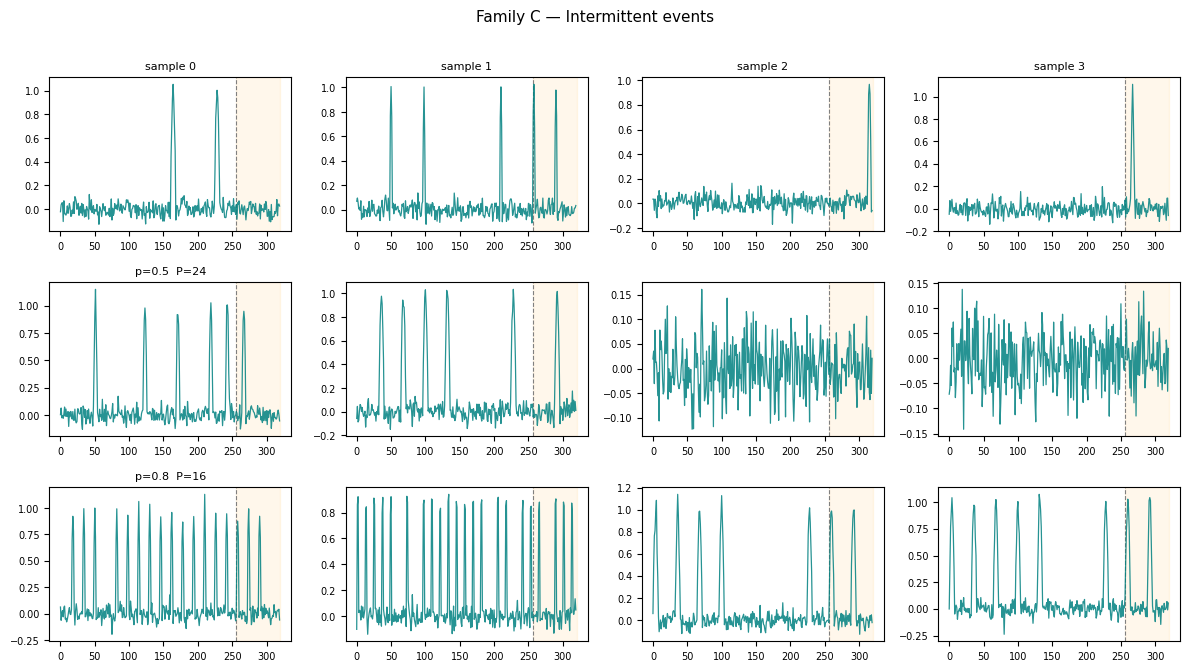

In [14]:
p_levels = cfg['family_c']['intermittent_p']

fig, axes = plt.subplots(len(p_levels), N_SAMPLES, figsize=(N_SAMPLES * 3, len(p_levels) * 2.2))
fig.suptitle('Family C — Intermittent events', fontsize=11, y=1.01)

for row, (li, p) in enumerate(zip(range(len(p_levels)), p_levels)):
    series, meta, _ = load('family_c_intermittent', f'p_{li:02d}')
    idxs = sample_idxs(len(series))
    for col, si in enumerate(idxs):
        ax = axes[row, col]
        title = f'p={p}  P={meta["period_ts"][si]:.0f}' if col == 0 else ''
        plot_series(ax, series[si], CTX, title=title, color='teal')
        if row == 0:
            ax.set_title(f'sample {col}', fontsize=8)

plt.tight_layout()
plt.show()

## Family C — Random-amplitude periodic
Rows = Var(A) level. Amplitude modulation becomes more extreme at higher variance.

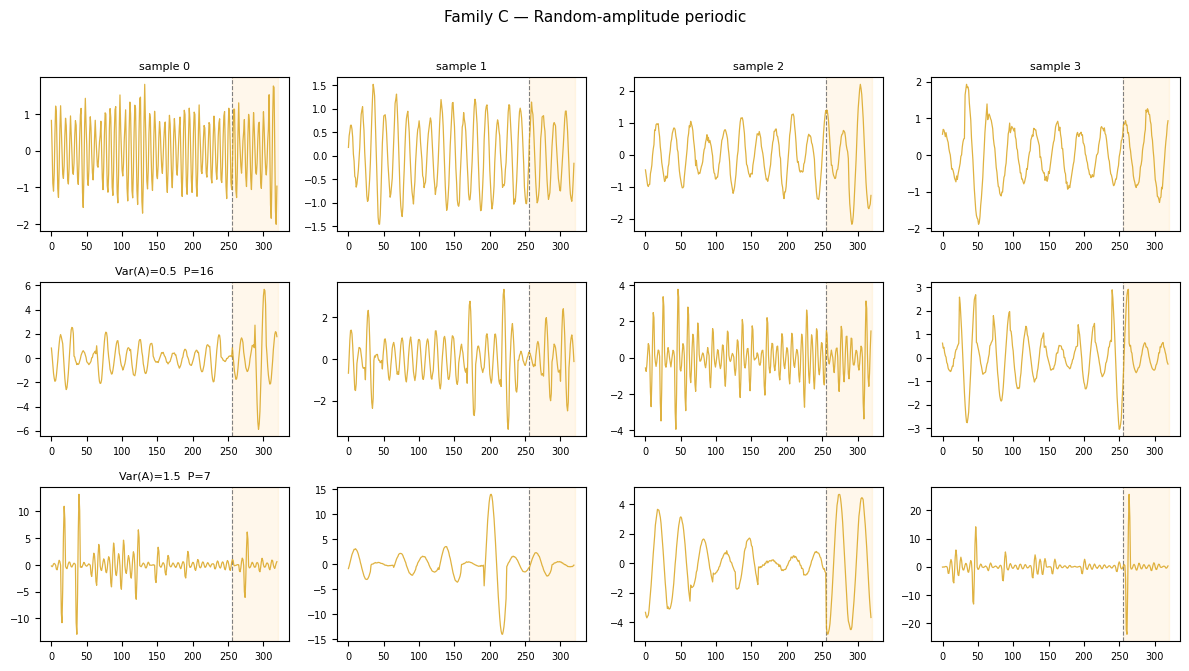

In [15]:
var_levels = cfg['family_c']['rand_amp_var_levels']

fig, axes = plt.subplots(len(var_levels), N_SAMPLES, figsize=(N_SAMPLES * 3, len(var_levels) * 2.2))
fig.suptitle('Family C — Random-amplitude periodic', fontsize=11, y=1.01)

for row, (li, var) in enumerate(zip(range(len(var_levels)), var_levels)):
    series, meta, _ = load('family_c_rand_amp', f'var_{li:02d}')
    idxs = sample_idxs(len(series))
    for col, si in enumerate(idxs):
        ax = axes[row, col]
        title = f'Var(A)={var}  P={meta["period_ts"][si]:.0f}' if col == 0 else ''
        plot_series(ax, series[si], CTX, title=title, color='goldenrod')
        if row == 0:
            ax.set_title(f'sample {col}', fontsize=8)

plt.tight_layout()
plt.show()

---
## Summary stats across all families

In [16]:
from collections import defaultdict

families_present = sorted(set(idx['families']))
print(f"{'Family':<30} {'Levels':>6} {'n/level':>8} {'series_shape':>14} {'NaN?':>6}")
print('-' * 70)

level_keys_by_family = defaultdict(list)
for f, lk in zip(idx['families'], idx['level_keys']):
    level_keys_by_family[f].append(lk)

for family in families_present:
    keys = level_keys_by_family[family]
    s, m, c = load(family, keys[0])
    has_nan = np.isnan(s).any()
    print(f"{family:<30} {len(keys):>6} {len(s):>8} {str(s.shape):>14} {str(has_nan):>6}")

Family                         Levels  n/level   series_shape   NaN?
----------------------------------------------------------------------
family_a_periodic                  10      256     (256, 320)  False
family_a_trend                     10      256     (256, 320)  False
family_a_white_noise                1      256     (256, 320)  False
family_b_outlier                    8      256     (256, 320)  False
family_b_phi                       11      256     (256, 320)  False
family_b_triangle                   3      256     (256, 320)  False
family_c_intermittent               3      256     (256, 320)  False
family_c_rand_amp                   3      256     (256, 320)  False
